In [9]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.utilities.sql_database import SQLDatabase
from sqlalchemy import create_engine
from sqlalchemy.pool import StaticPool

import sqlite3
import requests


In [10]:
load_dotenv(dotenv_path=".env", override=True)

llm = ChatOpenAI(model_name="meta-llama/Llama-3.1-70B-Instruct",temperature=0)


def create_db_engine():
    with open("utils/generate_data.db", "rb") as f:
        db_bytes = f.read()

    # Step 2 — Load it into in-memory SQLite
    in_memory_conn = sqlite3.connect(":memory:", check_same_thread=False)
    disk_conn = sqlite3.connect("utils/generate_data.db", check_same_thread=False)
    disk_conn.backup(in_memory_conn)  # copies all data from file into memory
    disk_conn.close()

engine = create_engine("sqlite:///utils/generate_data.db", creator = lambda: sqlite3.connect("utils/generate_data.db"), poolclass=StaticPool,
                        connect_args={"check_same_thread":False})

db= SQLDatabase(engine)

In [11]:
from langgraph.checkpoint.memory import MemorySaver # short-term memory
from langgraph.store.memory import InMemoryStore #persistent store

in_memory_store = InMemoryStore()

checkpointer = MemorySaver()

In [12]:
from typing_extensions import TypedDict
from typing import Annotated,List
from langgraph.graph.message import AnyMessage,add_messages
from langgraph.managed.is_last_step import RemainingSteps


class State(TypedDict):
    customer_id:str
    messages: Annotated[list[AnyMessage],add_messages]
    loaded_memory:str
    remaining_steps: RemainingSteps

In [13]:
from langchain_core.tools import tool
import ast

@tool
def get_transactions_by_account(customer: str):
    """Get Transaction by a customer"""

    return db.run(
        f"""SELECT CUSTOMER.CustomerId, CUSTOMER.FirstName FROM Customers JOIN Accounts ON Customers.CustomerId = AccountsCustomerId
        WHERE Customers.FirstName LIKE '%{customer}%'
        """,
        include_columns=True
    )

@tool
def get_loan_details_by_customer(customer:str):
    """Get Loan Details of Customer"""
    return db.run(
        f"""
        SELECT 
            Customers.FirstName,
            Customers.LastName,
            Accounts.AccountType,
            Loans.LoanID,
            Loans.LoanType,
            Loans.LoanAmount,
            Loans.InterestRate,
            Loans.StartDate,
            Loans.EndDate,
            Loans.Status
        FROM Customers
        LEFT JOIN Accounts ON Customers.CustomerID = Accounts.CustomerID
        LEFT JOIN Loans ON Customers.CustomerID = Loans.CustomerID
        WHERE Customers.FirstName LIKE '%{customer}%'
           OR Customers.LastName LIKE '%{customer}%'
        """,
        include_columns=True
    )

@tool
def get_products_by_category(category:str):
    """
    Fetch products from the database to match specific category

    Args:
        category(str): The category of products to fetch

    Returns:
        list[dict]: A list of products matching specific genre
    """
    return db.run(
        f"""
        SELECT Name, Category, InterestRate, Description
        FROM Products
        WHERE LOWER(Category) LIKE LOWER('%{category}%')
        """,
        include_columns=True
    )

@tool
def get_account_transactions(customer:str):
    """
    """
    return db.run(
        f"""
        SELECT Customers.FirstName, Accounts.AccountType, Transactions.Amount
        FROM Customers JOIN Accounts ON Customers.CustomerId = Accounts.CustomerId
        JOIN Transactions ON Transactions.AccountId= Accounts.AccountId
        WHERE Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%'
        ORDER BY Transactions.Date DESC
        """,
        include_columns=True
    )

@tool
def check_transaction_status(transaction_id: int):
    """
    Check the status and details of a specific transaction by its ID.

    Args:
        transaction_id (int): The unique transaction ID to look up.

    Returns:
        dict: Transaction details including amount, type, date and description.
    """
    return db.run(
        f"""
        SELECT 
            Transactions.TransactionId,
            Transactions.Date,
            Transactions.Amount,
            Transactions.Type,
            Transactions.Description,
            Customers.FirstName,
            Customers.LastName,
            Accounts.AccountType
        FROM Transactions
        JOIN Accounts ON Transactions.AccountId = Accounts.AccountId
        JOIN Customers ON Accounts.CustomerId = Customers.CustomerId
        WHERE Transactions.TransactionId = {transaction_id}
        """,
        include_columns=True
    )


banking_tools = [
    get_transactions_by_account,
    get_loan_details_by_customer,
    get_products_by_category,
    get_account_transactions,
    check_transaction_status
]

llm_with_banking_tools = llm.bind_tools(banking_tools)

In [14]:
from langgraph.prebuilt import ToolNode

banking_tool_node = ToolNode(banking_tools)

In [15]:
from langchain_core.messages import ToolMessage, SystemMessage, HumanMessage
from langchain_core.runnables import RunnableConfig


def generate_financial_assistant_prompt(memory:str = "None") -> str:
    return f"""
    
    
    """

def banking_assistant(state: State, config: RunnableConfig):
    memory = "None"

    if "loaded_memory" in state:
        memory = state["loaded_memory"]
    
    banking_assistant_prompt = generate_financial_assistant_prompt(memory)

    response = llm_with_banking_tools.invoke([SystemMessage(banking_assistant_prompt)] + state["messages"])

    return {"messages":[response]}

In [16]:
def should_continue(state:State, config:RunnableConfig):
    messages = state["messages"]
    last_message = messages[-1]


    if not last_message.tool_calls:
        return "end"

    else:
        return "continue"

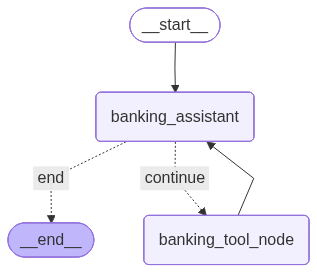

In [17]:
from langgraph.graph import StateGraph, START, END
from utils.visualization import show_graph

banking_workflow = StateGraph(State)

banking_workflow.add_node("banking_assistant",banking_assistant)
banking_workflow.add_node("banking_tool_node",banking_tool_node)

banking_workflow.add_edge(START, "banking_assistant")

banking_workflow.add_conditional_edges(
    "banking_assistant",
    should_continue,
    {
        "continue": "banking_tool_node",
        "end":END
    }
    )
banking_workflow.add_edge("banking_tool_node","banking_assistant")

banking_workflow_subagent = banking_workflow.compile(name="banking_workflow_subagent", checkpointer=checkpointer, store=in_memory_store)

show_graph(banking_workflow_subagent)



In [18]:
#Testing the built workflow

### Building ReAct Agent using LangGraph Pre-built: Statement & Payment History Sub-Agent

In [ ]:
from langhchain_core.tools import tool


@tool
def get_statements_by_customer(customer:str) -> list[dict]:
    """
    
    """
    return db.run(
        f"""
        SELECT 
            Customers.FirstName,
            Customers.LastName,
            Accounts.AccountType,
            Accounts.Balance,
            COUNT(Transactions.TransactionId) AS TotalTransactions,
            SUM(CASE WHEN Transactions.Type = 'Debit' THEN Transactions.Amount ELSE 0 END) AS TotalDebits,
            SUM(CASE WHEN Transactions.Type = 'Credit' THEN Transactions.Amount ELSE 0 END) AS TotalCredits
        FROM Customers
        JOIN Accounts ON Customers.CustomerId = Accounts.CustomerId
        LEFT JOIN Transactions ON Accounts.AccountId = Transactions.AccountId
        WHERE Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%'
        GROUP BY Accounts.AccountId
        """,
        include_columns=True
    )

@tool
def get_payment_history(customer:str):
    return db.run(
        f"""
        SELECT 
            Transactions.TransactionId,
            Transactions.Date,
            Transactions.Amount,
            Transactions.Type,
            Transactions.Description,
            Accounts.AccountType
        FROM Transactions
        JOIN Accounts ON Transactions.AccountId = Accounts.AccountId
        JOIN Customers ON Accounts.CustomerId = Customers.CustomerId
        WHERE Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%'
        ORDER BY Transactions.Date DESC
        LIMIT 20
        """,
        include_columns=True
    )

@tool
def get_monthly_spending_summary(customer: str):
    """Get a monthly breakdown of total debits and credits for a customer."""
    return db.run(
        f"""
        SELECT 
            strftime('%Y-%m', Transactions.Date) AS Month,
            SUM(CASE WHEN Transactions.Type = 'Debit' THEN Transactions.Amount ELSE 0 END) AS TotalSpent,
            SUM(CASE WHEN Transactions.Type = 'Credit' THEN Transactions.Amount ELSE 0 END) AS TotalReceived,
            COUNT(*) AS NumTransactions
        FROM Transactions
        JOIN Accounts ON Transactions.AccountId = Accounts.AccountId
        JOIN Customers ON Accounts.CustomerId = Customers.CustomerId
        WHERE Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%'
        GROUP BY Month
        ORDER BY Month DESC
        """,
        include_columns=True
    )

@tool
def get_large_transactions(customer: str):
    """Get all transactions above £500 for a customer — useful for flagging large payments."""
    return db.run(
        f"""
        SELECT 
            Transactions.Date,
            Transactions.Amount,
            Transactions.Type,
            Transactions.Description,
            Accounts.AccountType
        FROM Transactions
        JOIN Accounts ON Transactions.AccountId = Accounts.AccountId
        JOIN Customers ON Accounts.CustomerId = Customers.CustomerId
        WHERE (Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%')
        AND Transactions.Amount > 500
        ORDER BY Transactions.Amount DESC
        """,
        include_columns=True
    )

statement_tools = [
    get_statements_by_customer,
    get_payment_history,
    get_monthly_spending_summary,
    get_large_transactions
]